### Подключение PySpark, загрузка библиотек, настройка изображений

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, mean, countDistinct, count, size, when, regexp_extract, split

sns.set_style('darkgrid')
params = {'legend.fontsize' : 'medium', 'figure.figsize':(10, 8), 'figure.dpi': 100, 'axes.labelsize':'medium', 'axes.titlesize':'medium','xtick.labelsize':'medium', 'ytick.labelsize':'medium'}
plt.rcParams.update(params)

### Запуск сессии PySpark

In [2]:
spark = SparkSession.builder.appName('EDA Films').getOrCreate()

25/04/25 15:46:20 WARN Utils: Your hostname, Artems-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 192.168.0.149 instead (on interface en0)
25/04/25 15:46:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/25 15:46:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Загрузка и обзор датасетов

In [3]:
df_movies = spark.read.csv('sp_movies.csv', header=True, inferSchema=True)
df_ratings = spark.read.csv('sp_ratings.csv', header=True, inferSchema=True)
df_tags = spark.read.csv('sp_tags.csv', header=True, inferSchema=True)

In [4]:
df_movies.show(3)

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
+-------+--------------------+--------------------+
only showing top 3 rows



In [5]:
df_ratings.show(3)

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|   4.0|964982703|
|     1|      3|   4.0|964981247|
|     1|      6|   4.0|964982224|
+------+-------+------+---------+
only showing top 3 rows



In [6]:
df_tags.show(3)

+------+-------+---------------+----------+
|userId|movieId|            tag| timestamp|
+------+-------+---------------+----------+
|     2|  60756|          funny|1445714994|
|     2|  60756|Highly quotable|1445714996|
|     2|  60756|   will ferrell|1445714992|
+------+-------+---------------+----------+
only showing top 3 rows



### Статистика данных

In [7]:
print('Количество пользователей поставивших оценку:')
df_ratings.select(countDistinct('userId')).show()

Количество пользователей поставивших оценку:
+----------------------+
|count(DISTINCT userId)|
+----------------------+
|                   610|
+----------------------+



In [8]:
print('Количество оцененных фильмов:')
df_ratings.select(countDistinct('movieId')).show()

Количество оцененных фильмов:
+-----------------------+
|count(DISTINCT movieId)|
+-----------------------+
|                   9724|
+-----------------------+



In [9]:
print('Количество комментариев (tags) фильмов:')
df_tags.select(countDistinct('movieId')).show()

Количество комментариев (tags) фильмов:
+-----------------------+
|count(DISTINCT movieId)|
+-----------------------+
|                   1572|
+-----------------------+



In [10]:
print('Количество комментариев к фильмам:')
df_tags.select(countDistinct('tag')).show()

Количество комментариев к фильмам:
+-------------------+
|count(DISTINCT tag)|
+-------------------+
|               1589|
+-------------------+



### Предобработка и настройка данных

In [11]:
df1 = df_ratings.alias('df1')
df2 = df_tags.alias('df2')
df3 = df_movies.alias('df3')

In [12]:
df3.show()

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
|      6|         Heat (1995)|Action|Crime|Thri...|
|      7|      Sabrina (1995)|      Comedy|Romance|
|      8| Tom and Huck (1995)|  Adventure|Children|
|      9| Sudden Death (1995)|              Action|
|     10|    GoldenEye (1995)|Action|Adventure|...|
|     11|American Presiden...|Comedy|Drama|Romance|
|     12|Dracula: Dead and...|       Comedy|Horror|
|     13|        Balto (1995)|Adventure|Animati...|
|     14|        Nixon (1995)|               Drama|
|     15|Cutthroat Island ...|Action|Adventure|...|
|     16|       Casino (1995)|         Crime|Drama|
|     17|Sen

### Извлечение года из названия

In [13]:
df3 = df3.withColumn('year', regexp_extract(df3['title'], r'\((\d{4})\)', 1))

In [14]:
df3.show()

+-------+--------------------+--------------------+----+
|movieId|               title|              genres|year|
+-------+--------------------+--------------------+----+
|      1|    Toy Story (1995)|Adventure|Animati...|1995|
|      2|      Jumanji (1995)|Adventure|Childre...|1995|
|      3|Grumpier Old Men ...|      Comedy|Romance|1995|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|1995|
|      5|Father of the Bri...|              Comedy|1995|
|      6|         Heat (1995)|Action|Crime|Thri...|1995|
|      7|      Sabrina (1995)|      Comedy|Romance|1995|
|      8| Tom and Huck (1995)|  Adventure|Children|1995|
|      9| Sudden Death (1995)|              Action|1995|
|     10|    GoldenEye (1995)|Action|Adventure|...|1995|
|     11|American Presiden...|Comedy|Drama|Romance|1995|
|     12|Dracula: Dead and...|       Comedy|Horror|1995|
|     13|        Balto (1995)|Adventure|Animati...|1995|
|     14|        Nixon (1995)|               Drama|1995|
|     15|Cutthroat Island ...|A

In [15]:
df_movies.show()

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
|      6|         Heat (1995)|Action|Crime|Thri...|
|      7|      Sabrina (1995)|      Comedy|Romance|
|      8| Tom and Huck (1995)|  Adventure|Children|
|      9| Sudden Death (1995)|              Action|
|     10|    GoldenEye (1995)|Action|Adventure|...|
|     11|American Presiden...|Comedy|Drama|Romance|
|     12|Dracula: Dead and...|       Comedy|Horror|
|     13|        Balto (1995)|Adventure|Animati...|
|     14|        Nixon (1995)|               Drama|
|     15|Cutthroat Island ...|Action|Adventure|...|
|     16|       Casino (1995)|         Crime|Drama|
|     17|Sen

### Извлечение информации о жанрах

In [16]:
split_expr = split(df3['genres'], '\\|')
for i in range(1, 11):
    df3 = df3.withColumn('genre{}'.format(i), split_expr.getItem(i-1))

genre_colunms = {'genre{}'.format(i) for i in range(1, 11)}
for col_name in genre_colunms:
    df3 = df3.withColumn(col_name, col(col_name).cast('string').alias(col_name))

genre_count_expr = sum(when(col(col_name) != '0', 1).otherwise(0) for col_name in genre_colunms)
df3 = df3.withColumn('genre_count', genre_count_expr)

In [17]:
df3.show()

+-------+--------------------+--------------------+----+---------+---------+--------+------+--------+------+------+------+------+-------+-----------+
|movieId|               title|              genres|year|   genre1|   genre2|  genre3|genre4|  genre5|genre6|genre7|genre8|genre9|genre10|genre_count|
+-------+--------------------+--------------------+----+---------+---------+--------+------+--------+------+------+------+------+-------+-----------+
|      1|    Toy Story (1995)|Adventure|Animati...|1995|Adventure|Animation|Children|Comedy| Fantasy|  NULL|  NULL|  NULL|  NULL|   NULL|          5|
|      2|      Jumanji (1995)|Adventure|Childre...|1995|Adventure| Children| Fantasy|  NULL|    NULL|  NULL|  NULL|  NULL|  NULL|   NULL|          3|
|      3|Grumpier Old Men ...|      Comedy|Romance|1995|   Comedy|  Romance|    NULL|  NULL|    NULL|  NULL|  NULL|  NULL|  NULL|   NULL|          2|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|1995|   Comedy|    Drama| Romance|  NULL|    NULL

In [18]:
df3 = df3.drop('genres')

In [19]:
df3.show()

+-------+--------------------+----+---------+---------+--------+------+--------+------+------+------+------+-------+-----------+
|movieId|               title|year|   genre1|   genre2|  genre3|genre4|  genre5|genre6|genre7|genre8|genre9|genre10|genre_count|
+-------+--------------------+----+---------+---------+--------+------+--------+------+------+------+------+-------+-----------+
|      1|    Toy Story (1995)|1995|Adventure|Animation|Children|Comedy| Fantasy|  NULL|  NULL|  NULL|  NULL|   NULL|          5|
|      2|      Jumanji (1995)|1995|Adventure| Children| Fantasy|  NULL|    NULL|  NULL|  NULL|  NULL|  NULL|   NULL|          3|
|      3|Grumpier Old Men ...|1995|   Comedy|  Romance|    NULL|  NULL|    NULL|  NULL|  NULL|  NULL|  NULL|   NULL|          2|
|      4|Waiting to Exhale...|1995|   Comedy|    Drama| Romance|  NULL|    NULL|  NULL|  NULL|  NULL|  NULL|   NULL|          3|
|      5|Father of the Bri...|1995|   Comedy|     NULL|    NULL|  NULL|    NULL|  NULL|  NULL|  N

### Анализ данных

In [20]:
df1.show()

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|   4.0|964982703|
|     1|      3|   4.0|964981247|
|     1|      6|   4.0|964982224|
|     1|     47|   5.0|964983815|
|     1|     50|   5.0|964982931|
|     1|     70|   3.0|964982400|
|     1|    101|   5.0|964980868|
|     1|    110|   4.0|964982176|
|     1|    151|   5.0|964984041|
|     1|    157|   5.0|964984100|
|     1|    163|   5.0|964983650|
|     1|    216|   5.0|964981208|
|     1|    223|   3.0|964980985|
|     1|    231|   5.0|964981179|
|     1|    235|   4.0|964980908|
|     1|    260|   5.0|964981680|
|     1|    296|   3.0|964982967|
|     1|    316|   3.0|964982310|
|     1|    333|   5.0|964981179|
|     1|    349|   4.0|964982563|
+------+-------+------+---------+
only showing top 20 rows



In [21]:
rating_avg = df1.groupBy('movieId').agg(mean('rating').alias('rating_avg'))
rating_avg = rating_avg.withColumnRenamed('movieId', 'movieId_avg')
rating_avg.show(3)

+-----------+-----------------+
|movieId_avg|       rating_avg|
+-----------+-----------------+
|       1580|3.487878787878788|
|       2366|             3.64|
|       3175|             3.58|
+-----------+-----------------+
only showing top 3 rows



In [22]:
rating_count = df1.groupby('movieId').agg(count('rating').alias('rating_count'))
rating_count = rating_count.withColumnRenamed('movieId', 'movieId_count')
rating_count.show(3)

+-------------+------------+
|movieId_count|rating_count|
+-------------+------------+
|         1580|         165|
|         2366|          25|
|         3175|          75|
+-------------+------------+
only showing top 3 rows



In [23]:
user_rating = df1.groupBy('userId').agg(mean('rating').alias('user_rating_avg'))
user_rating = user_rating.withColumnRenamed('userId', 'userId_avg')
user_rating.show(3)

+----------+------------------+
|userId_avg|   user_rating_avg|
+----------+------------------+
|       148|3.7395833333333335|
|       463| 3.787878787878788|
|       471|             3.875|
+----------+------------------+
only showing top 3 rows



In [24]:
user_count = df1.groupBy('userId').agg(count('rating').alias('user_rating_count'))
user_count = user_count.withColumnRenamed('userId', 'userId_count')
user_count.show(3)

+------------+-----------------+
|userId_count|user_rating_count|
+------------+-----------------+
|         148|               48|
|         463|               33|
|         471|               28|
+------------+-----------------+
only showing top 3 rows



In [25]:
df_movie = rating_avg.join(rating_count, col('movieId_avg') == col('movieId_count'), 'inner').drop('movieId_count')
df_movie.show(3)

+-----------+-----------------+------------+
|movieId_avg|       rating_avg|rating_count|
+-----------+-----------------+------------+
|       1580|3.487878787878788|         165|
|       2366|             3.64|          25|
|       3175|             3.58|          75|
+-----------+-----------------+------------+
only showing top 3 rows



In [26]:
df_user = user_rating.join(user_count, col('userId_avg') == col('userId_count'), 'inner').drop('userId_count')
df_user.show(3)

+----------+------------------+-----------------+
|userId_avg|   user_rating_avg|user_rating_count|
+----------+------------------+-----------------+
|       148|3.7395833333333335|               48|
|       463| 3.787878787878788|               33|
|       471|             3.875|               28|
+----------+------------------+-----------------+
only showing top 3 rows



In [27]:
df_user.sort(col('user_rating_count').desc()).show()

+----------+------------------+-----------------+
|userId_avg|   user_rating_avg|user_rating_count|
+----------+------------------+-----------------+
|       414| 3.391957005189029|             2698|
|       599|2.6420500403551253|             2478|
|       474| 3.398956356736243|             2108|
|       448|2.8473712446351933|             1864|
|       274| 3.235884101040119|             1346|
|       610|3.6885560675883258|             1302|
|        68| 3.233730158730159|             1260|
|       380|3.6732348111658455|             1218|
|       606|3.6573991031390136|             1115|
|       288|3.1459715639810426|             1055|
|       249|3.6964627151051626|             1046|
|       387|3.2585199610516065|             1027|
|       182|3.5112589559877176|              977|
|       307|2.6656410256410257|              975|
|       603|3.5079533404029695|              943|
|       298| 2.363684771033014|              939|
|       177| 3.375553097345133|              904|


In [28]:
df_movie.sort(col('rating_avg').desc()).show()

+-----------+----------+------------+
|movieId_avg|rating_avg|rating_count|
+-----------+----------+------------+
|      26350|       5.0|           1|
|       3795|       5.0|           1|
|      25887|       5.0|           1|
|     157775|       5.0|           1|
|        633|       5.0|           1|
|      33138|       5.0|           1|
|      67618|       5.0|           1|
|        876|       5.0|           1|
|        496|       5.0|           1|
|      27373|       5.0|           1|
|     113829|       5.0|           1|
|      53578|       5.0|           1|
|     152711|       5.0|           1|
|     118894|       5.0|           1|
|         53|       5.0|           2|
|     160644|       5.0|           1|
|        148|       5.0|           1|
|       8911|       5.0|           1|
|     147300|       5.0|           1|
|      84273|       5.0|           1|
+-----------+----------+------------+
only showing top 20 rows



In [29]:
df_movies = df_movie.withColumnRenamed('movieId_avg', 'movieId')

In [30]:
dfk = df3.select('movieId', df3['genre1'])
df2 = df2.join(dfk, on = 'movieId', how='inner')

In [31]:
df2.show()

+-------+------+----------------+----------+---------+
|movieId|userId|             tag| timestamp|   genre1|
+-------+------+----------------+----------+---------+
|      1|   567|             fun|1525286013|Adventure|
|      1|   474|           pixar|1137206825|Adventure|
|      1|   336|           pixar|1139045764|Adventure|
|      2|   474|            game|1137375552|Adventure|
|      2|    62|  Robin Williams|1528843907|Adventure|
|      2|    62|magic board game|1528843932|Adventure|
|      2|    62|         fantasy|1528843929|Adventure|
|      3|   289|             old|1143424860|   Comedy|
|      3|   289|           moldy|1143424860|   Comedy|
|      5|   474|          remake|1137373903|   Comedy|
|      5|   474|       pregnancy|1137373903|   Comedy|
|      7|   474|          remake|1137375642|   Comedy|
|     11|   474|       president|1137374904|   Comedy|
|     11|   474|        politics|1137374904|   Comedy|
|     14|   474|       president|1137375623|    Drama|
|     14| 

In [32]:
df_movie_renamed = df_movie.withColumnRenamed('movieId_avg', 'movieId')

In [33]:
df3 = df3.join(df_movie_renamed, on='movieId', how='inner')

In [34]:
df3.show(3)

+-------+--------------------+----+---------+---------+-------+------+------+------+------+------+------+-------+-----------+-----------------+------------+
|movieId|               title|year|   genre1|   genre2| genre3|genre4|genre5|genre6|genre7|genre8|genre9|genre10|genre_count|       rating_avg|rating_count|
+-------+--------------------+----+---------+---------+-------+------+------+------+------+------+------+-------+-----------+-----------------+------------+
|   1580|Men in Black (a.k...|1997|   Action|   Comedy| Sci-Fi|  NULL|  NULL|  NULL|  NULL|  NULL|  NULL|   NULL|          3|3.487878787878788|         165|
|   2366|    King Kong (1933)|1933|   Action|Adventure|Fantasy|Horror|  NULL|  NULL|  NULL|  NULL|  NULL|   NULL|          4|             3.64|          25|
|   3175| Galaxy Quest (1999)|1999|Adventure|   Comedy| Sci-Fi|  NULL|  NULL|  NULL|  NULL|  NULL|  NULL|   NULL|          3|             3.58|          75|
+-------+--------------------+----+---------+---------+---

In [35]:
df3 = df3.withColumnRenamed('rating_avg', 'rating')

### Лучшие фильмы по жанрам

In [36]:
df3.groupBy('genre1') \
    .agg({'rating': 'avg', 'rating_count': 'sum'}) \
    .withColumnRenamed('avg(rating)', 'avg_rating') \
    .withColumnRenamed('sum(rating_count)', 'total_vote') \
    .orderBy(col('avg_rating').desc()) \
    .show()
    

+------------------+------------------+----------+
|            genre1|        avg_rating|total_vote|
+------------------+------------------+----------+
|         Film-Noir|3.8562184343434347|       112|
|       Documentary|3.7889134809499603|      1015|
|         Animation| 3.574865409400964|      2549|
|               War|             3.525|         9|
|           Western|3.4715869878913357|       151|
|             Drama|3.4609149865486173|     17068|
|             Crime|3.4122601226160905|      6610|
|(no genres listed)|3.3711484593837535|        47|
|         Adventure|3.2851788575659153|     10344|
|           Musical| 3.276388888888889|       134|
|           Romance|3.2052944862155393|       125|
|            Comedy| 3.193690704718599|     25217|
|           Fantasy|3.1797741128192873|       315|
|           Mystery|3.1481526997179983|       976|
|            Action|3.0944984491955116|     30635|
|            Sci-Fi|3.0669590956205637|       343|
|          Thriller| 3.00717008

### Фильмы с высоким рейтингом (при условии min голосов)

In [41]:
df3.filter(col('rating_count') > 100) \
    .orderBy(col('rating').desc()) \
    .select('title', 'year', 'rating', 'rating_count') \
    .show(10, truncate=False)

+-----------------------------------------+----+-----------------+------------+
|title                                    |year|rating           |rating_count|
+-----------------------------------------+----+-----------------+------------+
|Shawshank Redemption, The (1994)         |1994|4.429022082018927|317         |
|Godfather, The (1972)                    |1972|4.2890625        |192         |
|Fight Club (1999)                        |1999|4.272935779816514|218         |
|Godfather: Part II, The (1974)           |1974|4.25968992248062 |129         |
|Departed, The (2006)                     |2006|4.252336448598131|107         |
|Goodfellas (1990)                        |1990|4.25             |126         |
|Dark Knight, The (2008)                  |2008|4.238255033557047|149         |
|Usual Suspects, The (1995)               |1995|4.237745098039215|204         |
|Princess Bride, The (1987)               |1987|4.232394366197183|142         |
|Star Wars: Episode IV - A New Hope (197

### Распределение рейтингов по годам

In [43]:
df3.groupBy('year') \
    .avg('rating') \
    .withColumnRenamed('avg(rating)', 'avg_rating') \
    .orderBy('year') \
    .show(20)

+----+------------------+
|year|        avg_rating|
+----+------------------+
|    |3.7115384615384617|
|1902|               3.5|
|1903|               2.5|
|1908|               4.0|
|1915|               2.0|
|1916|            3.5625|
|1917|               4.5|
|1919|               2.0|
|1920| 3.678571428571429|
|1921|               4.1|
|1922|           3.53125|
|1923|            3.5625|
|1924|               3.7|
|1925| 3.680357142857143|
|1926|               4.0|
|1927|3.2653061224489797|
|1928|3.7145833333333336|
|1929|3.5833333333333335|
|1930|             3.995|
|1931| 3.263539891481068|
+----+------------------+
only showing top 20 rows



### Средний рейтинг по жанрам

In [44]:
genre_avg = df3.groupBy('genre1') \
    .agg({'rating': 'avg'}) \
    .withColumnRenamed('avg(rating)', 'avg_rating') \
    .orderBy('avg_rating', ascending = False)

pdf = genre_avg.toPandas()

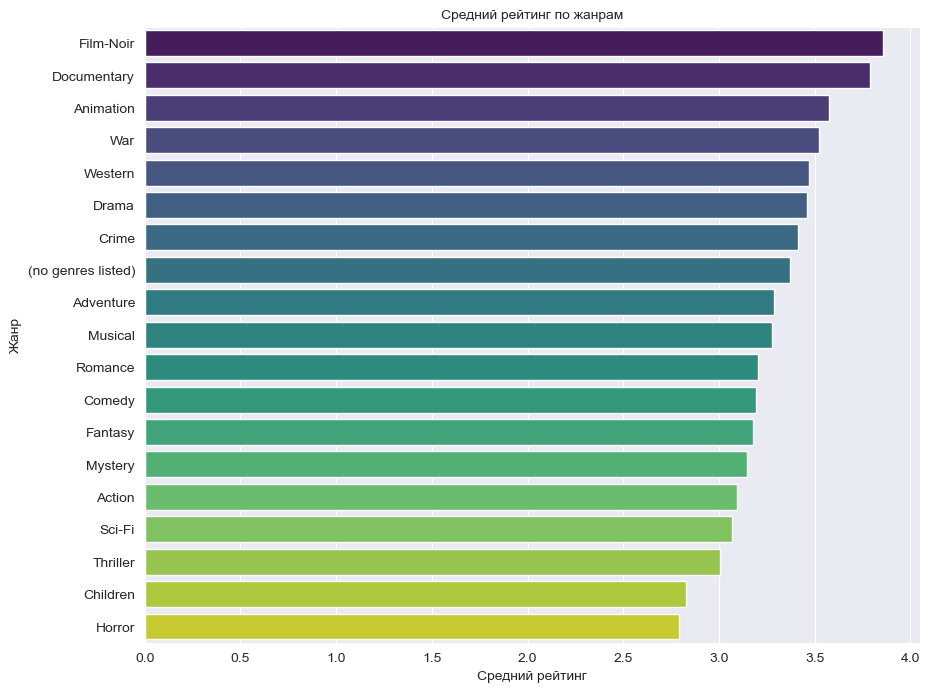

In [48]:
sns.barplot(data=pdf, x='avg_rating', y='genre1', palette='viridis')
plt.title('Средний рейтинг по жанрам')
plt.xlabel('Средний рейтинг')
plt.ylabel('Жанр')
plt.show()

### Диаграмма рассеяния "Рейтинг - Кол-во голосов"

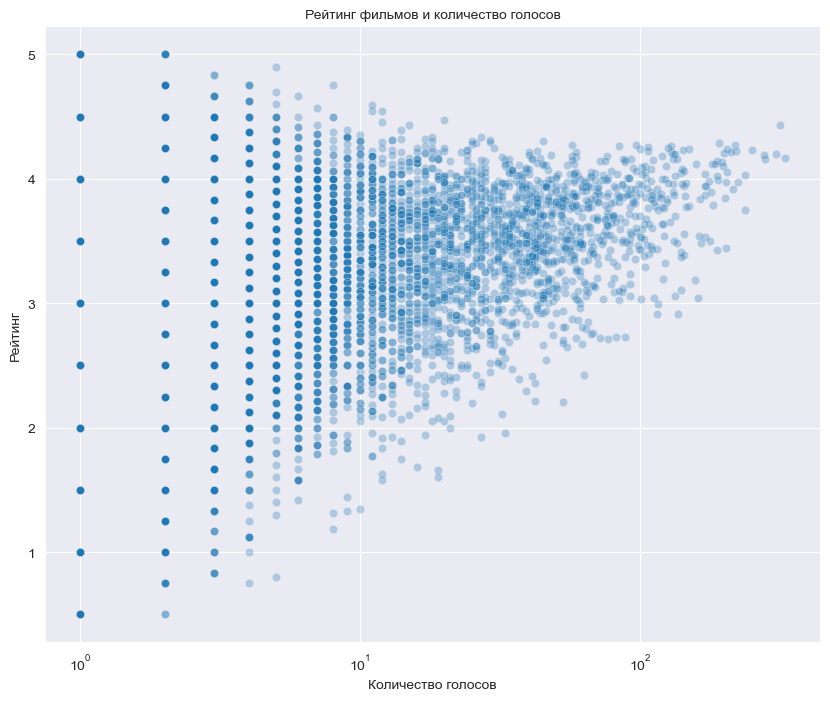

In [58]:
top = df3.filter(df3.rating_count > 0).select('rating', 'rating_count').toPandas()

sns.scatterplot(data=top, x='rating_count', y = 'rating', alpha = 0.3)
plt.title('Рейтинг фильмов и количество голосов')
plt.xlabel('Количество голосов')
plt.ylabel('Рейтинг')
plt.xscale('log')
plt.show()

In [59]:
spark.stop()